# CLBD GPS Station Data Analysis

This notebook analyzes high-rate GNSS data from the CLBD (Carlsbad) GPS station in San Diego County.

**Station Information:**
- Station ID: CLBD.CI.LY_.20
- Location: Carlsbad, CA
- Coordinates: (-117.311, 33.135)
- Data Period: December 2023 - December 2024
- Sampling Rate: 1 Hz (high-rate)
- Provider: EarthScope Consortium

## 1. Install Required Packages

In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## 3. Load and Explore Data

In [3]:
# Load the CSV data
data_path = 'CLBD/CLBD.CI.LY_.20.csv'
df = pd.read_csv(data_path)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (837484, 8)

Column Names: ['time', 'east', 'north', 'up', 'sigEE', 'sigNN', 'sigUU', 'qChannel']

First few rows:


,time,east,north,up,sigEE,sigNN,sigUU,qChannel
0,1733184000000,-0.027,0.024,0.096,0.031,0.033,0.069,1610041
1,1733184001000,-0.029,0.024,0.091,0.031,0.033,0.069,1610041
2,1733184002000,-0.028,0.023,0.086,0.031,0.033,0.069,1610041
3,1733184003000,-0.026,0.024,0.088,0.031,0.033,0.069,1610041
4,1733184004000,-0.026,0.024,0.081,0.031,0.033,0.069,1610041


In [4]:
# Data types and missing values
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())


Data Types:
time          int64
east        float64
north       float64
up          float64
sigEE       float64
sigNN       float64
sigUU       float64
qChannel      int64
dtype: object

Missing Values:
time        0
east        0
north       0
up          0
sigEE       0
sigNN       0
sigUU       0
qChannel    0
dtype: int64


In [5]:
# Convert timestamp to datetime
df['datetime'] = pd.to_datetime(df['time'], unit='ms')
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour

# Display time range
print(f"Time Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Duration: {df['datetime'].max() - df['datetime'].min()}")
print(f"Total Data Points: {len(df):,}")

Time Range: 2024-12-03 00:00:00 to 2024-12-12 17:59:59
Duration: 9 days 17:59:59
Total Data Points: 837,484


## 4. Statistical Summary

In [6]:
# Statistical summary of position data
position_cols = ['east', 'north', 'up']
error_cols = ['sigEE', 'sigNN', 'sigUU']

print("Position Statistics (meters):")
print(df[position_cols].describe())

print("\nError Statistics (meters):")
print(df[error_cols].describe())

Position Statistics (meters):
                east          north             up
count  837484.000000  837484.000000  837484.000000
mean       -0.020740       0.006933       0.043519
std         0.117924       0.079846       0.229087
min        -2.862000      -2.812000      -3.979000
25%        -0.025000       0.001000       0.021000
50%        -0.021000       0.008000       0.037000
75%        -0.017000       0.015000       0.054000
max         3.865000       3.182000      12.345000

Error Statistics (meters):
               sigEE          sigNN          sigUU
count  837484.000000  837484.000000  837484.000000
mean        0.059909       0.054246       0.110993
std         0.274969       0.205787       0.409704
min         0.027000       0.032000       0.063000
25%         0.030000       0.037000       0.073000
50%         0.032000       0.040000       0.081000
75%         0.035000       0.043000       0.091000
max        10.504000      18.395000      23.620000


## 5. Time Series Visualization

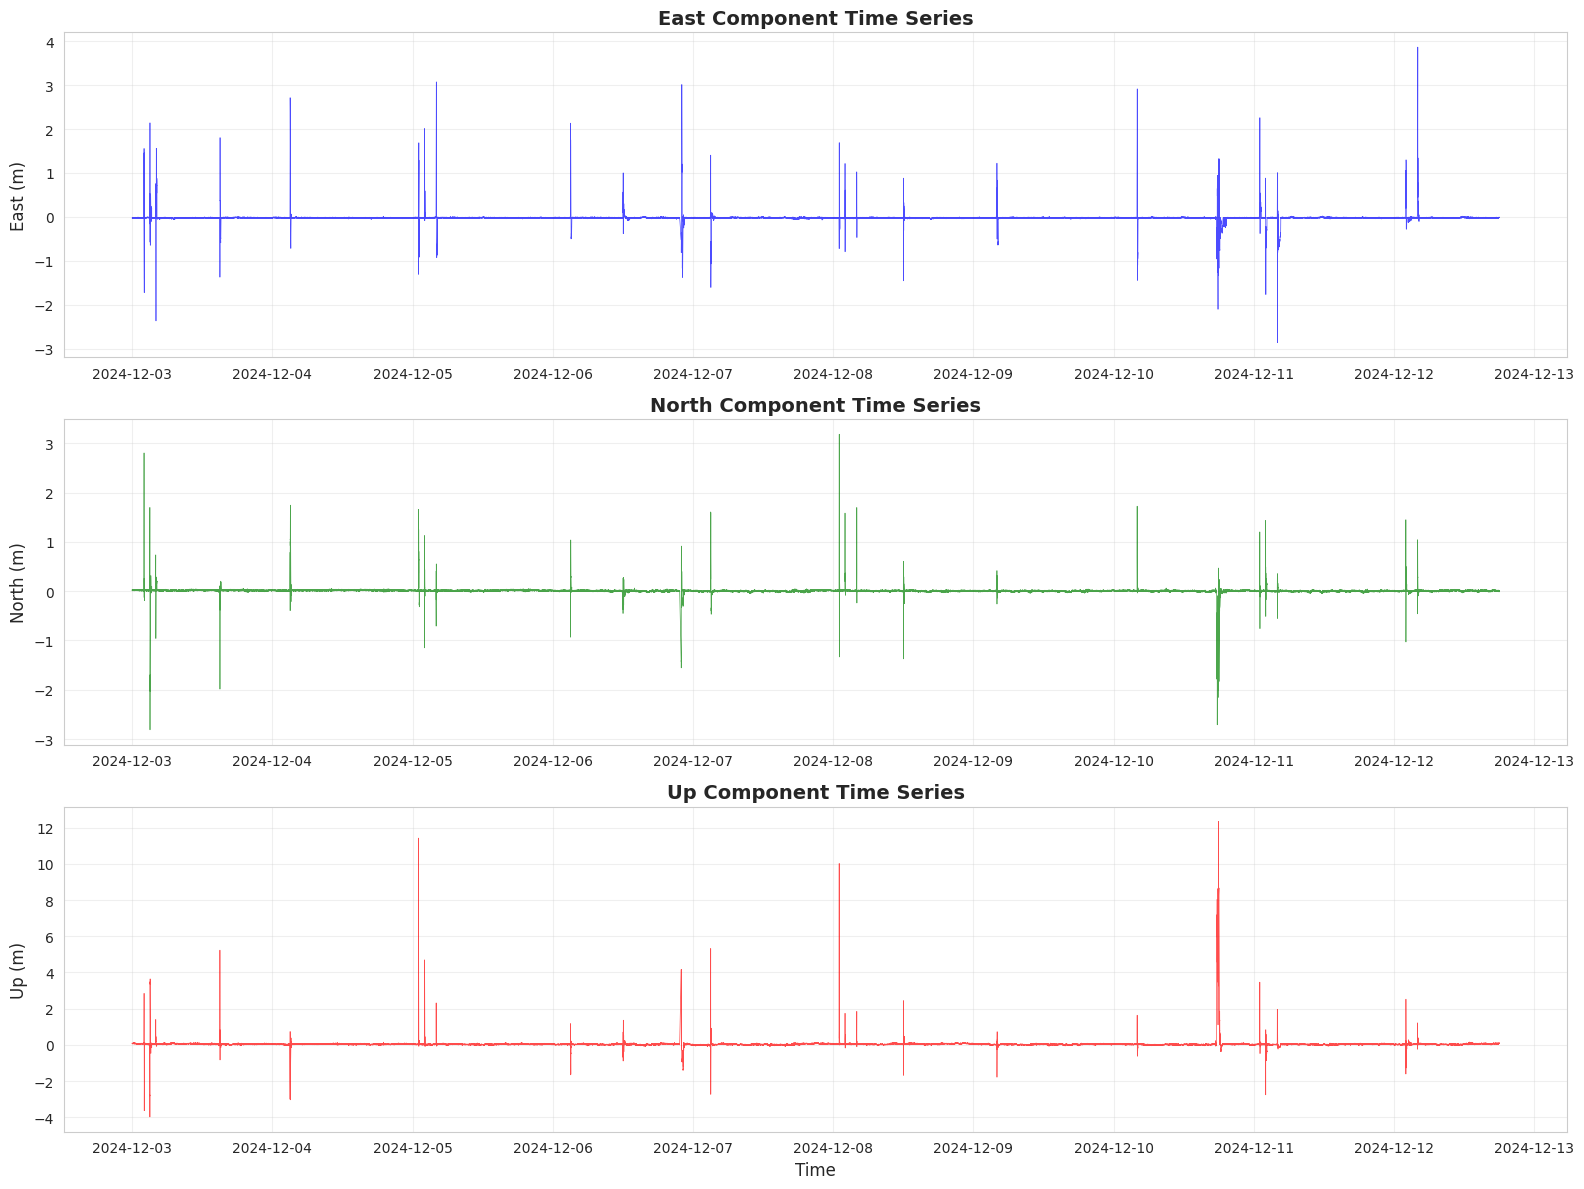

In [7]:
# Plot time series for all three components
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# East component
axes[0].plot(df['datetime'], df['east'], linewidth=0.5, alpha=0.7, color='blue')
axes[0].set_ylabel('East (m)', fontsize=12)
axes[0].set_title('East Component Time Series', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# North component
axes[1].plot(df['datetime'], df['north'], linewidth=0.5, alpha=0.7, color='green')
axes[1].set_ylabel('North (m)', fontsize=12)
axes[1].set_title('North Component Time Series', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Up component
axes[2].plot(df['datetime'], df['up'], linewidth=0.5, alpha=0.7, color='red')
axes[2].set_ylabel('Up (m)', fontsize=12)
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_title('Up Component Time Series', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CLBD_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Position Distribution Analysis

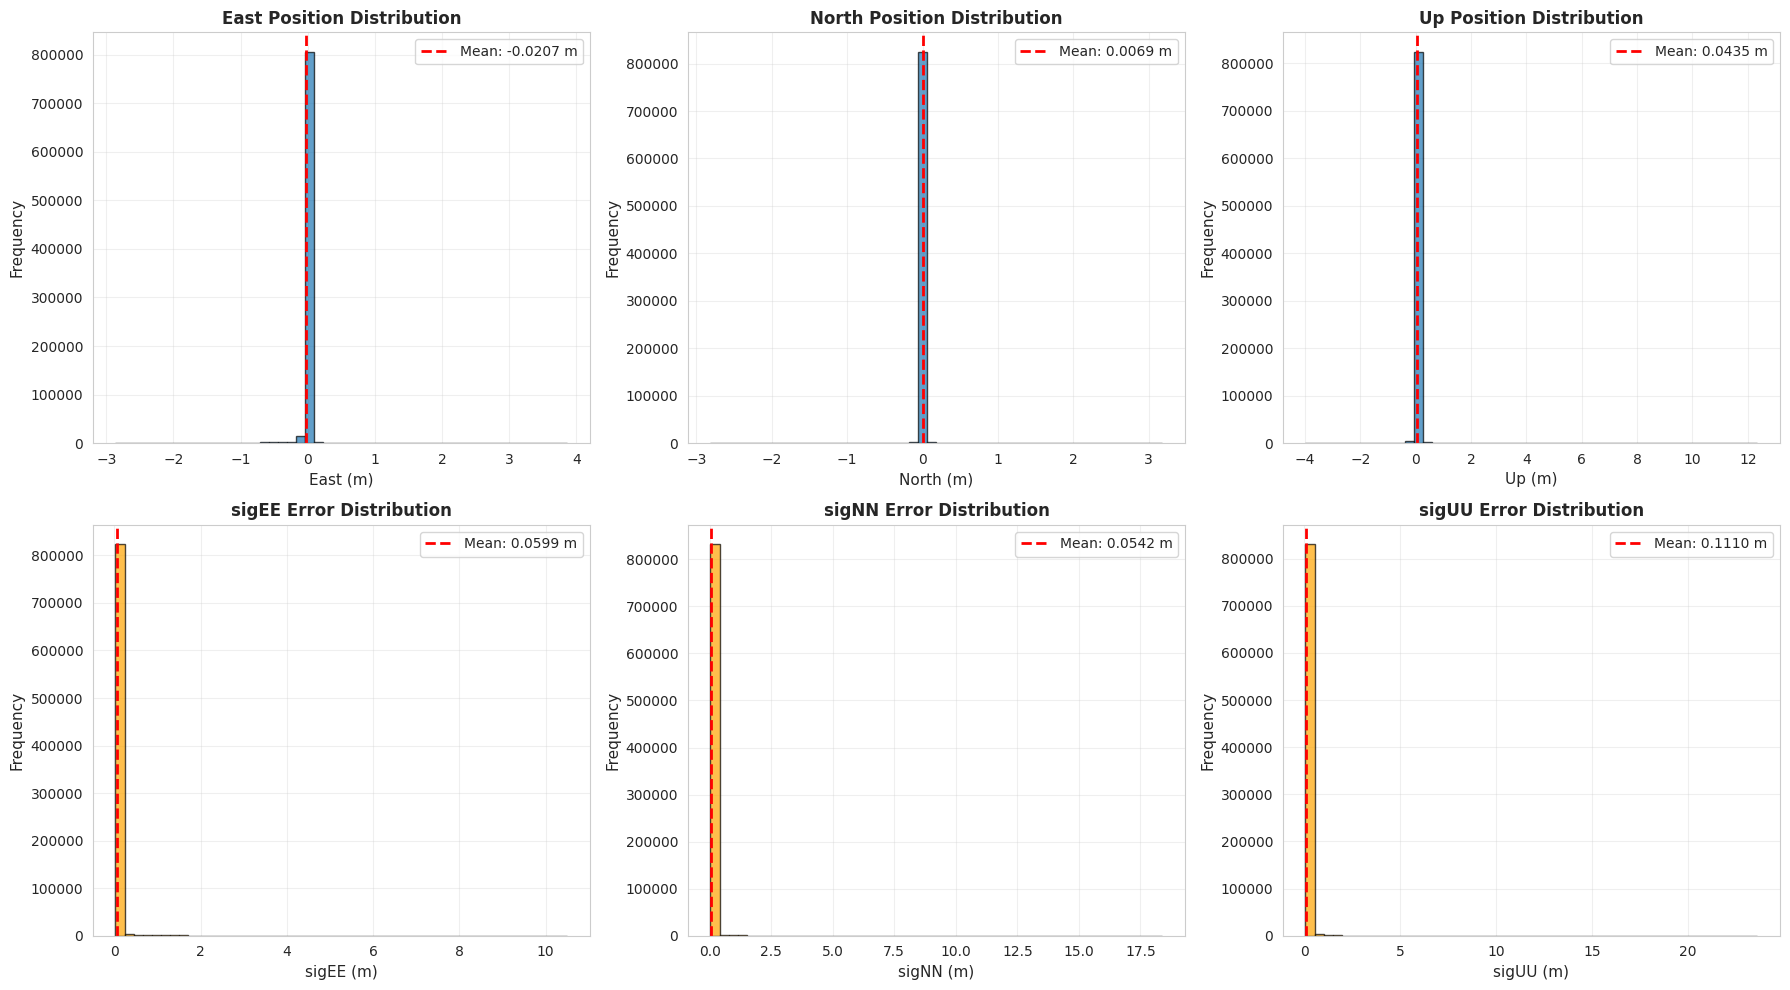

In [8]:
# Histograms of position components
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Position histograms
for idx, col in enumerate(position_cols):
    axes[0, idx].hist(df[col], bins=50, alpha=0.7, edgecolor='black')
    axes[0, idx].set_xlabel(f'{col.capitalize()} (m)', fontsize=11)
    axes[0, idx].set_ylabel('Frequency', fontsize=11)
    axes[0, idx].set_title(f'{col.capitalize()} Position Distribution', fontsize=12, fontweight='bold')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = df[col].mean()
    std_val = df[col].std()
    axes[0, idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f} m')
    axes[0, idx].legend()

# Error histograms
for idx, col in enumerate(error_cols):
    axes[1, idx].hist(df[col], bins=50, alpha=0.7, edgecolor='black', color='orange')
    axes[1, idx].set_xlabel(f'{col} (m)', fontsize=11)
    axes[1, idx].set_ylabel('Frequency', fontsize=11)
    axes[1, idx].set_title(f'{col} Error Distribution', fontsize=12, fontweight='bold')
    axes[1, idx].grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = df[col].mean()
    axes[1, idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f} m')
    axes[1, idx].legend()

plt.tight_layout()
plt.savefig('CLBD_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Analysis

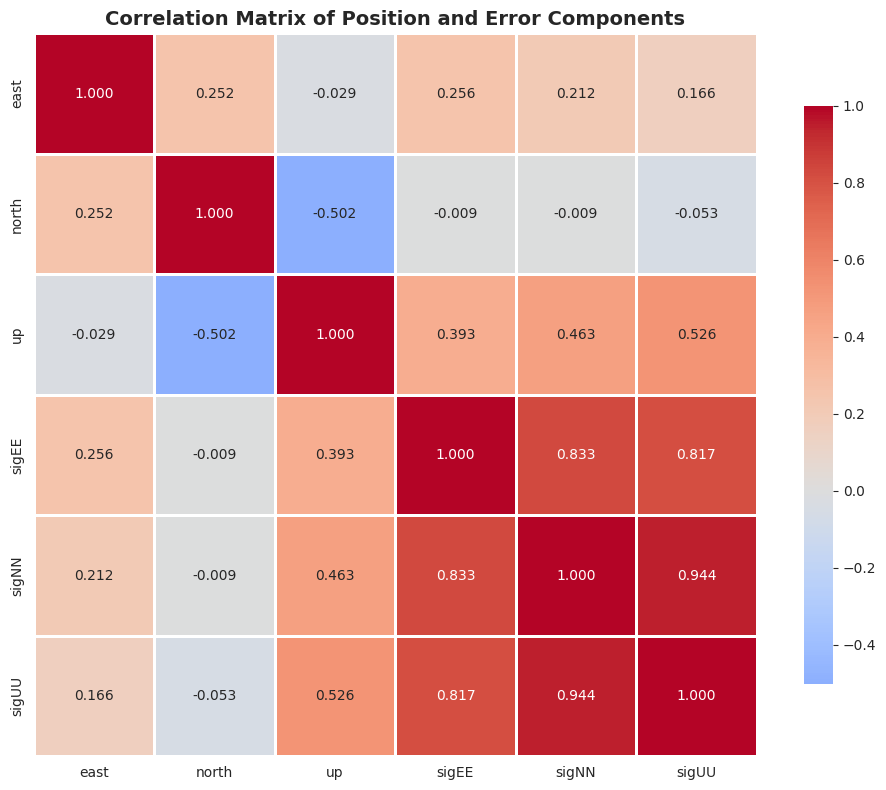

In [9]:
# Correlation matrix
correlation_cols = position_cols + error_cols
correlation_matrix = df[correlation_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title('Correlation Matrix of Position and Error Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('CLBD_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Scatter Plot: East vs North

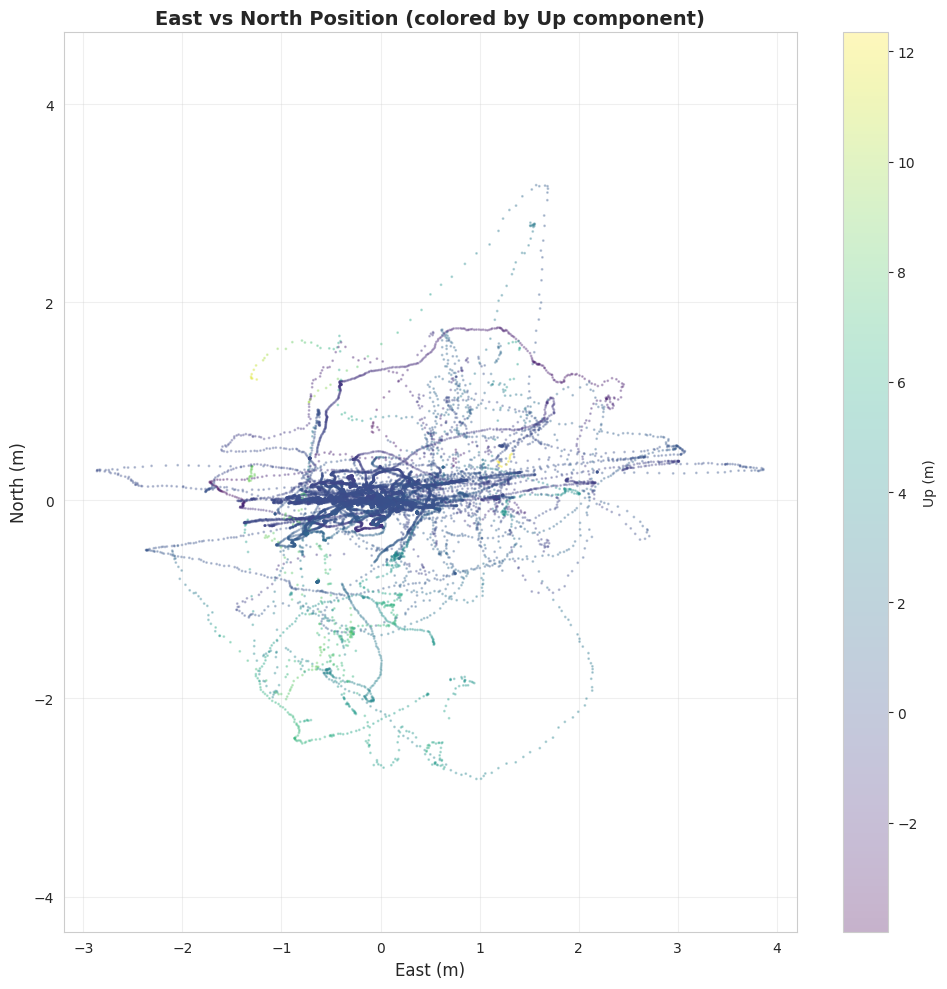

In [10]:
# Scatter plot of East vs North positions
plt.figure(figsize=(10, 10))
plt.scatter(df['east'], df['north'], alpha=0.3, s=1, c=df['up'], cmap='viridis')
plt.xlabel('East (m)', fontsize=12)
plt.ylabel('North (m)', fontsize=12)
plt.title('East vs North Position (colored by Up component)', fontsize=14, fontweight='bold')
plt.colorbar(label='Up (m)')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig('CLBD_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Daily Statistics

In [11]:
# Calculate daily statistics
daily_stats = df.groupby('date').agg({
    'east': ['mean', 'std', 'min', 'max'],
    'north': ['mean', 'std', 'min', 'max'],
    'up': ['mean', 'std', 'min', 'max']
}).round(6)

print("Daily Statistics:")
daily_stats.head(10)

Daily Statistics:


east                             north                   \
                mean       std    min    max      mean       std    min   
date                                                                      
2024-12-03 -0.018510  0.134217 -2.367  2.141  0.011570  0.119320 -2.812   
2024-12-04 -0.017830  0.099274 -0.717  2.713  0.021812  0.080386 -0.396   
2024-12-05 -0.013203  0.152002 -1.307  3.073  0.015167  0.053925 -1.150   
2024-12-06 -0.015813  0.161569 -1.379  3.013  0.006544  0.057155 -1.556   
2024-12-07 -0.024503  0.064898 -1.606  1.406  0.002199  0.042941 -0.468   
2024-12-08 -0.020595  0.064630 -1.454  1.690  0.005604  0.082566 -1.374   
2024-12-09 -0.021876  0.048593 -0.642  1.222  0.002334  0.012482 -0.261   
2024-12-10 -0.032042  0.125995 -2.102  2.914 -0.007213  0.149762 -2.711   
2024-12-11 -0.030425  0.131908 -2.862  2.258  0.003145  0.043385 -0.760   
2024-12-12 -0.010030  0.137923 -0.280  3.865  0.008303  0.049063 -1.031   

                         up                           
              max      mean       std    min     max  
date                                                  
2024-12-03  2.803  0.057961  0.227111 -3.979   5.234  
2024-12-04  1.744  0.034809  0.139158 -3.033   0.739  
2024-12-05  1.660  0.048592  0.224776 -0.081  11.423  
2024-12-06  1.038  0.023594  0.152704 -1.653   4.165  
2024-12-07  1.606  0.031779  0.099927 -2.731   5.326  
2024-12-08  3.182  0.059381  0.142307 -1.681  10.022  
2024-12-09  0.416  0.030461  0.039546 -1.782   0.728  
2024-12-10  1.723  0.079616  0.566490 -0.624  12.345  
2024-12-11  1.434  0.027971  0.099840 -2.757   3.466  
2024-12-12  1.448  0.040669  0.081645 -1.608   2.524

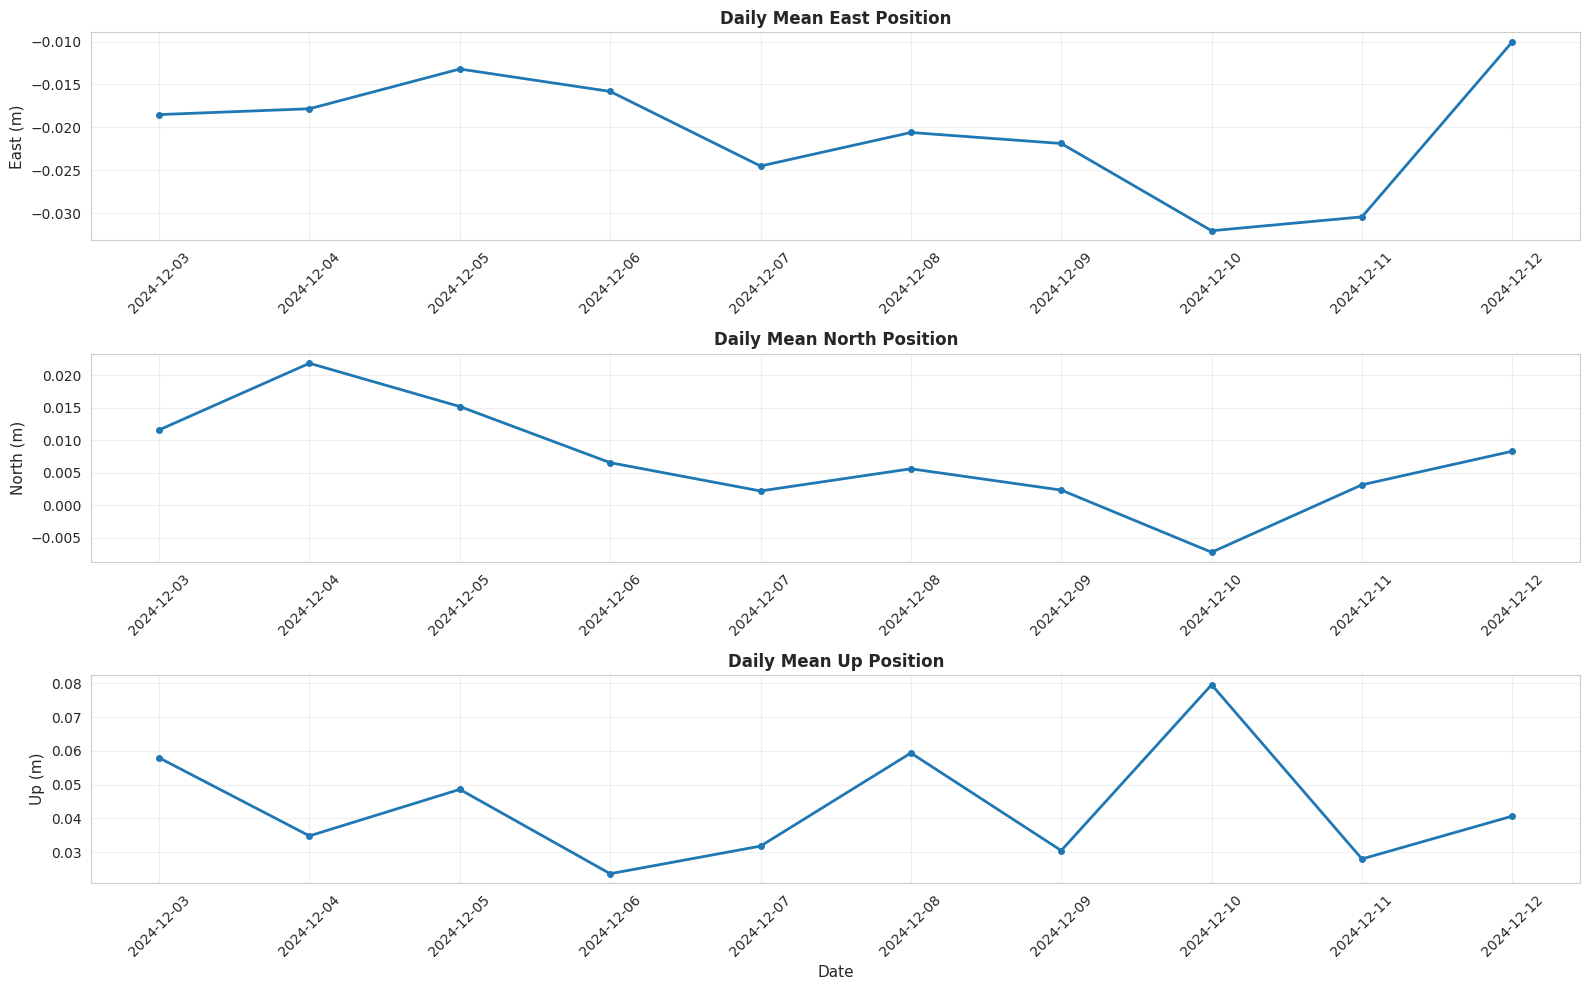

In [12]:
# Plot daily mean positions
daily_means = df.groupby('date')[position_cols].mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for idx, col in enumerate(position_cols):
    axes[idx].plot(daily_means.index, daily_means[col], marker='o', linewidth=2, markersize=4)
    axes[idx].set_ylabel(f'{col.capitalize()} (m)', fontsize=11)
    axes[idx].set_title(f'Daily Mean {col.capitalize()} Position', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

axes[2].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.savefig('CLBD_daily_means.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Hourly Pattern Analysis

In [13]:
# Calculate hourly statistics
hourly_stats = df.groupby('hour').agg({
    'east': ['mean', 'std'],
    'north': ['mean', 'std'],
    'up': ['mean', 'std']
}).round(6)

print("Hourly Statistics:")
hourly_stats

Hourly Statistics:


east               north                  up          
          mean       std      mean       std      mean       std
hour                                                            
0    -0.019101  0.005434  0.008063  0.008115  0.036236  0.023977
1    -0.006613  0.152225  0.013021  0.125586  0.058226  0.332803
2    -0.019975  0.181065  0.017949  0.108176  0.026149  0.327745
3    -0.010524  0.240892  0.013769  0.215077  0.021059  0.375375
4    -0.024619  0.371757  0.018370  0.107137  0.047389  0.146423
5    -0.020038  0.005500  0.010892  0.006914  0.040611  0.022714
6    -0.018370  0.007381  0.003066  0.009979  0.035653  0.022517
7    -0.020396  0.006742  0.003951  0.009498  0.030529  0.024328
8    -0.020179  0.004741  0.008996  0.007793  0.029885  0.018697
9    -0.018947  0.005200  0.004121  0.013301  0.029346  0.024485
10   -0.020425  0.005485  0.010204  0.009972  0.041247  0.026440
11   -0.017636  0.007949  0.005860  0.012514  0.032194  0.022106
12   -0.012706  0.074271  0.001629  0.065574  0.042402  0.118758
13   -0.021946  0.006712  0.010111  0.008869  0.037432  0.029628
14   -0.022219  0.005354  0.003406  0.011452  0.030690  0.024456
15   -0.021623  0.081924  0.003964  0.055488  0.038518  0.150533
16   -0.025119  0.007044  0.001535  0.015463  0.027037  0.019018
17   -0.029089  0.100836 -0.012482  0.211499  0.127978  0.735790
18   -0.034243  0.097526 -0.004208  0.088878  0.090967  0.497315
19   -0.028201  0.028851  0.006238  0.012697  0.049421  0.018358
20   -0.021422  0.005222  0.010607  0.008768  0.044900  0.020091
21   -0.021870  0.010499  0.008136  0.031909  0.054390  0.089655
22   -0.022328  0.215978  0.007059  0.056398  0.036404  0.201031
23   -0.023019  0.004670  0.011635  0.006073  0.044567  0.021613

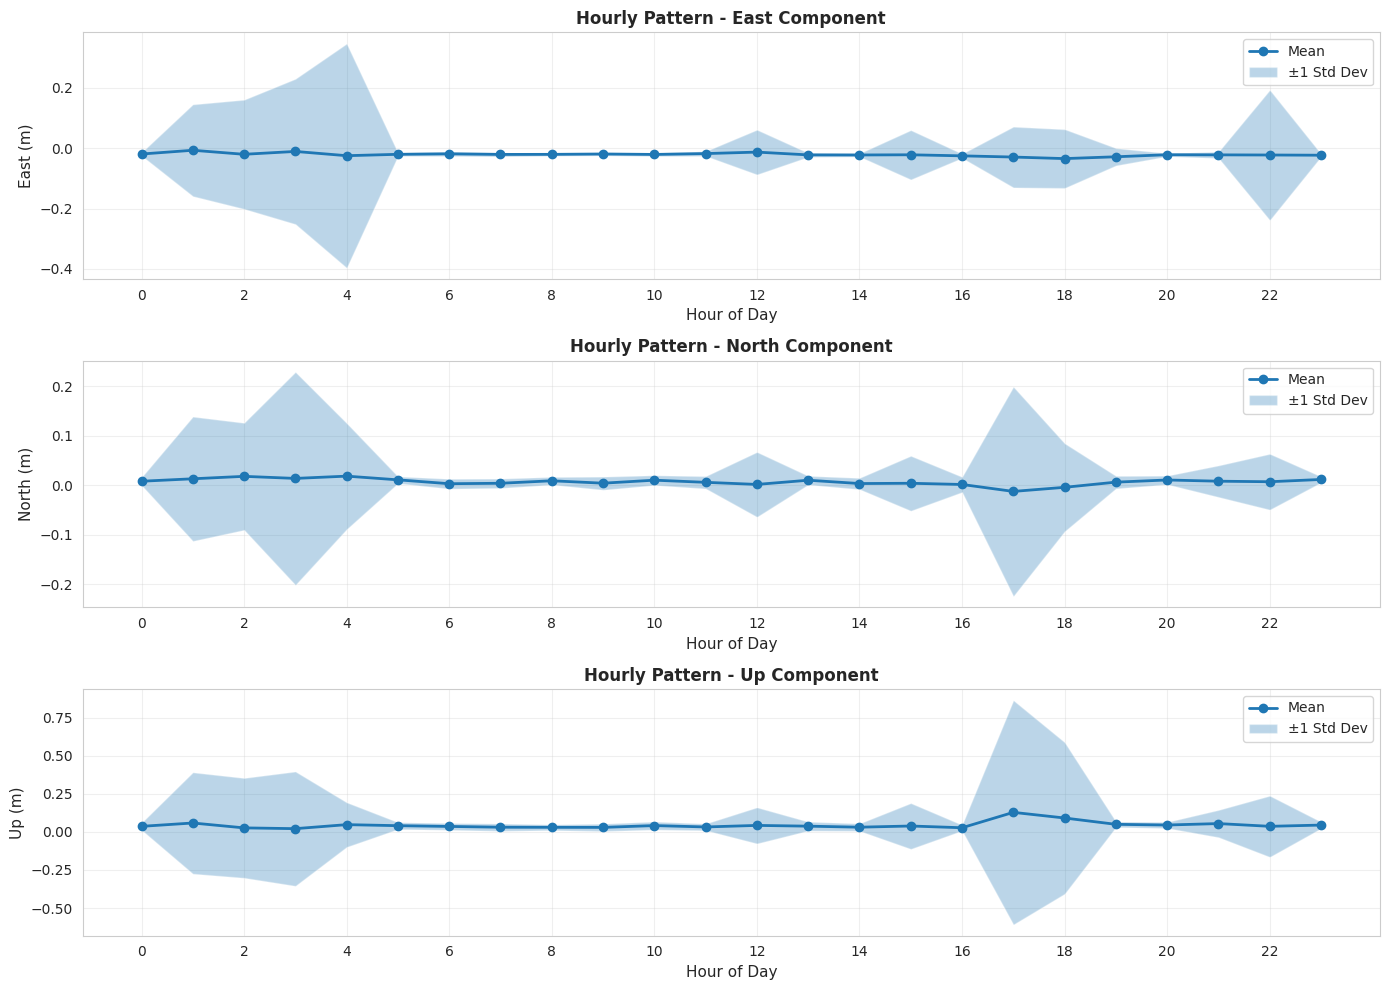

In [14]:
# Plot hourly patterns
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, col in enumerate(position_cols):
    hourly_mean = df.groupby('hour')[col].mean()
    hourly_std = df.groupby('hour')[col].std()
    
    axes[idx].plot(hourly_mean.index, hourly_mean, marker='o', linewidth=2, markersize=6, label='Mean')
    axes[idx].fill_between(hourly_mean.index, 
                         hourly_mean - hourly_std, 
                         hourly_mean + hourly_std, 
                         alpha=0.3, label='±1 Std Dev')
    axes[idx].set_ylabel(f'{col.capitalize()} (m)', fontsize=11)
    axes[idx].set_title(f'Hourly Pattern - {col.capitalize()} Component', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Hour of Day', fontsize=11)
    axes[idx].set_xticks(range(0, 24, 2))
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('CLBD_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Data Quality Assessment

In [15]:
# Check for outliers using z-score
def detect_outliers(data, threshold=3):
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold

outlier_counts = {}
for col in position_cols:
    outliers = detect_outliers(df[col])
    outlier_counts[col] = outliers.sum()
    print(f"{col.capitalize()}: {outliers.sum()} outliers ({outliers.sum()/len(df)*100:.2f}%)")

# Quality channel analysis
print(f"\nQuality Channel Statistics:")
print(df['qChannel'].describe())
print(f"\nUnique Quality Values: {df['qChannel'].nunique()}")

East: 11062 outliers (1.32%)
North: 5573 outliers (0.67%)
Up: 4635 outliers (0.55%)

Quality Channel Statistics:
count    8.374840e+05
mean     1.970115e+06
std      3.910244e+05
min      1.311041e+06
25%      1.709041e+06
50%      1.908041e+06
75%      2.108041e+06
max      1.300504e+07
Name: qChannel, dtype: float64

Unique Quality Values: 130


## 12. Summary and Conclusions

In [16]:
print("="*60)
print("CLBD GPS STATION DATA ANALYSIS SUMMARY")
print("="*60)
print(f"\nStation: CLBD (Carlsbad, CA)")
print(f"Data Points: {len(df):,}")
print(f"Time Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Duration: {df['datetime'].max() - df['datetime'].min()}")
print(f"\nPosition Statistics (meters):")
print(f"  East:   Mean = {df['east'].mean():.6f}, Std = {df['east'].std():.6f}")
print(f"  North:  Mean = {df['north'].mean():.6f}, Std = {df['north'].std():.6f}")
print(f"  Up:     Mean = {df['up'].mean():.6f}, Std = {df['up'].std():.6f}")
print(f"\nError Statistics (meters):")
print(f"  sigEE:  Mean = {df['sigEE'].mean():.6f}, Std = {df['sigEE'].std():.6f}")
print(f"  sigNN:  Mean = {df['sigNN'].mean():.6f}, Std = {df['sigNN'].std():.6f}")
print(f"  sigUU:  Mean = {df['sigUU'].mean():.6f}, Std = {df['sigUU'].std():.6f}")
print(f"\nData Quality:")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  Outliers (>3σ): {sum(outlier_counts.values())}")
print("\n" + "="*60)

CLBD GPS STATION DATA ANALYSIS SUMMARY

Station: CLBD (Carlsbad, CA)
Data Points: 837,484
Time Range: 2024-12-03 00:00:00 to 2024-12-12 17:59:59
Duration: 9 days 17:59:59

Position Statistics (meters):
  East:   Mean = -0.020740, Std = 0.117924
  North:  Mean = 0.006933, Std = 0.079846
  Up:     Mean = 0.043519, Std = 0.229087

Error Statistics (meters):
  sigEE:  Mean = 0.059909, Std = 0.274969
  sigNN:  Mean = 0.054246, Std = 0.205787
  sigUU:  Mean = 0.110993, Std = 0.409704

Data Quality:
  Missing Values: 0
  Outliers (>3σ): 21270

